svr - salary prediction
-----------------------------------
r2 score: 0.14
mse: 604049021.48


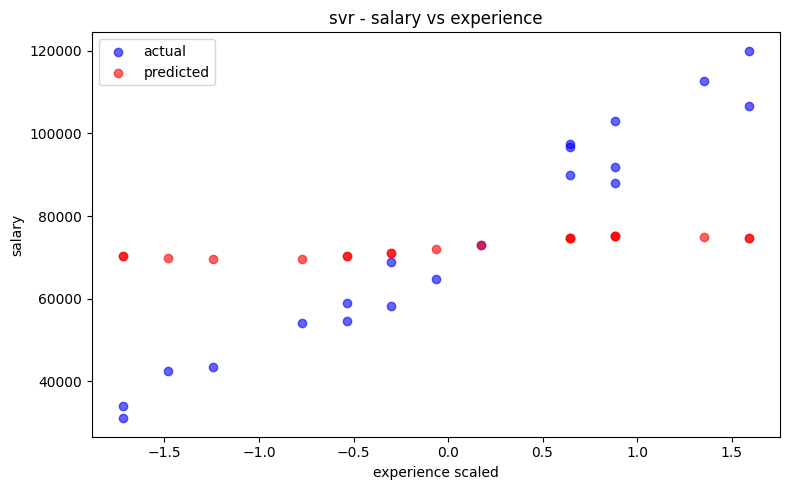

In [3]:
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 100

experience = np.random.randint(0, 15, n)
salary = experience * 6000 + np.random.randint(-8000, 8000, n) + 30000

x = experience.reshape(-1, 1)
y = salary

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

model = SVR(kernel="rbf", C=100)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("svr - salary prediction")
print("-" * 35)
print("r2 score:", round(r2_score(y_test, y_pred), 3))
print("mse:", round(mean_squared_error(y_test, y_pred), 2))

plt.figure(figsize=(8, 5))
plt.scatter(x_test, y_test, color="blue", label="actual", alpha=0.6)
plt.scatter(x_test, y_pred, color="red", label="predicted", alpha=0.6)
plt.title("svr - salary vs experience")
plt.xlabel("experience scaled")
plt.ylabel("salary")
plt.legend()
plt.tight_layout()
plt.show()